# Analisis Topik

WordCloud, BERTopic, TF-IDF, dan LDA per kelas sentimen.


In [ ]:
# Jalankan 01_preprocessing.ipynb terlebih dahulu.
import pickle
import pandas as pd

data_new = pd.read_pickle("data_preprocessed_with_emoticon.pkl")
with open("split_data.pkl", "rb") as file:
    split_data = pickle.load(file)

X_train_lstm = split_data["X_train_lstm"]
X_test_lstm = split_data["X_test_lstm"]
X_train_bert = split_data["X_train_bert"]
X_test_bert = split_data["X_test_bert"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]


#Tujuan No.2

WORDCLOUD

In [ ]:
#WORDCLOUD SETELAH PREPROCESSING
from wordcloud import WordCloud
import matplotlib.pyplot as plt

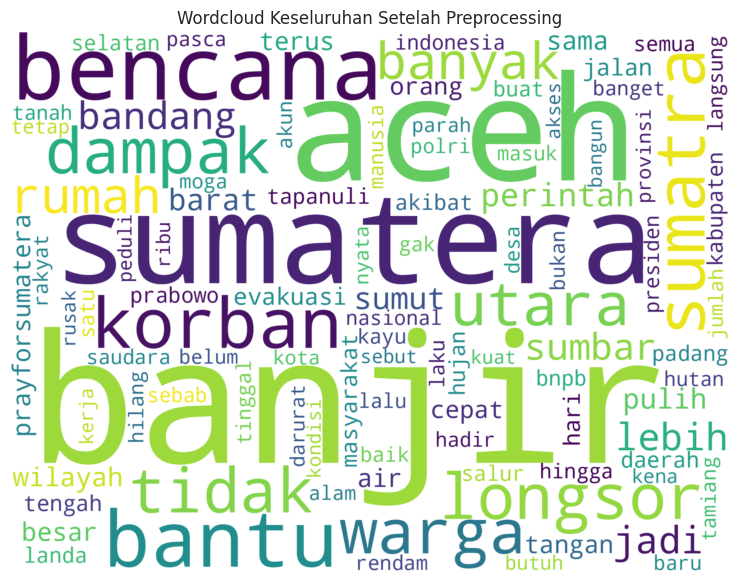

In [ ]:
#Wordcloud keseluruhan
text_all = ' '.join(data_new['clean_text_lstm'].dropna())

wc = WordCloud(
    width=2000,
    height=1500,
    max_words=100,
    background_color='white',
    collocations=False
).generate(text_all)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud Keseluruhan Setelah Preprocessing")
plt.show()

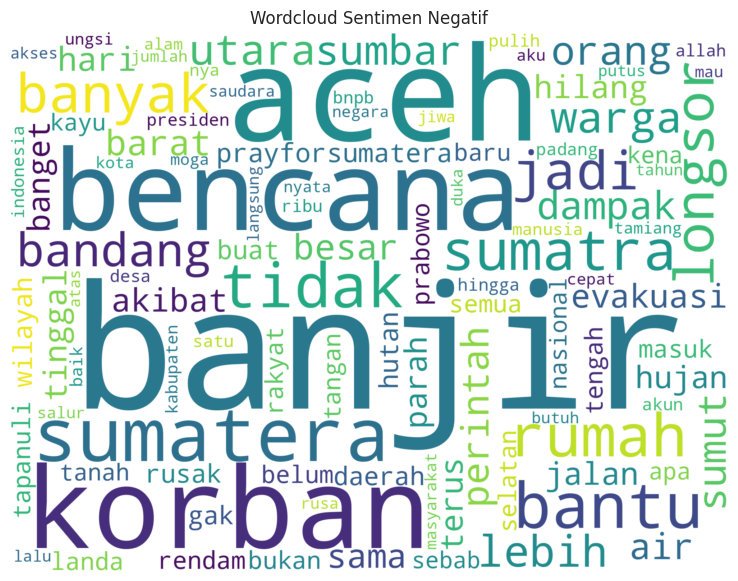

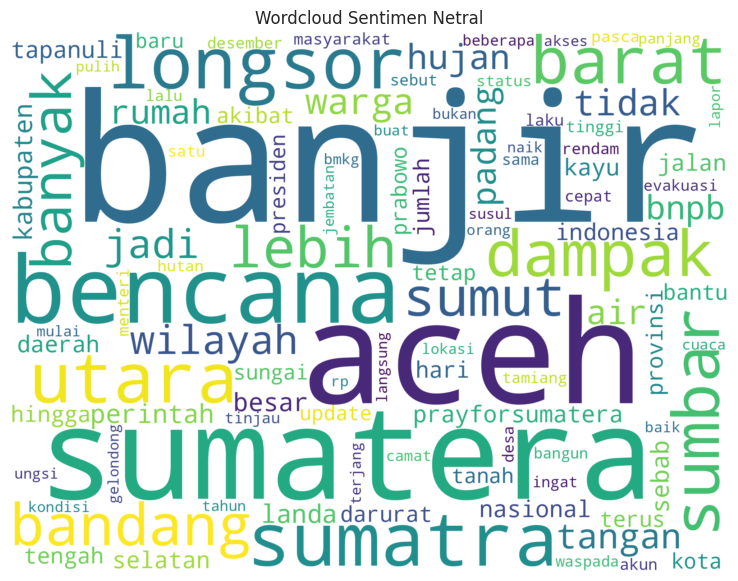

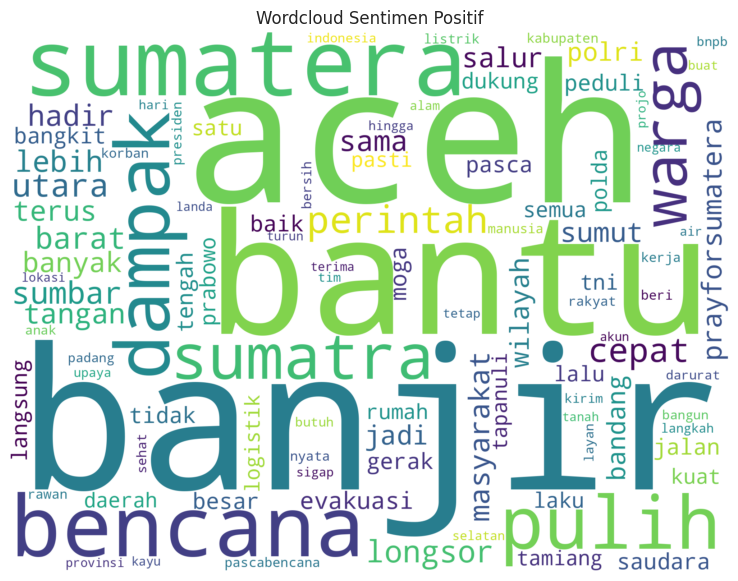

In [ ]:
#Wordcloud per kelas sentimen
label_list = ['negatif', 'netral', 'positif']

for label in label_list:
    text_label = ' '.join(
        data_new.loc[data_new['sentimen'] == label, 'clean_text_lstm'].dropna()
    )

    wc = WordCloud(
        width=2000,
        height=1500,
        max_words=100,
        background_color='white',
        collocations=False
    ).generate(text_label)

    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud Sentimen {label.capitalize()}")
    plt.show()

In [ ]:
#ambil kata dominan
from collections import Counter

def top_words(text_series, n=20):
    words = ' '.join(text_series.dropna()).split()
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=['kata', 'frekuensi'])

top_negatif = top_words(data_new.loc[data_new['sentimen'] == 'negatif', 'clean_text_lstm'])
top_netral = top_words(data_new.loc[data_new['sentimen'] == 'netral', 'clean_text_lstm'])
top_positif = top_words(data_new.loc[data_new['sentimen'] == 'positif', 'clean_text_lstm'])

print("Top kata negatif")
display(top_negatif)

print("Top kata netral")
display(top_netral)

print("Top kata positif")
display(top_positif)

Top kata negatif


,kata,frekuensi
0,banjir,4932
1,aceh,2571
2,korban,1857
3,bencana,1826
4,sumatera,1805
5,bantu,1248
6,tidak,1191
7,rumah,1095
8,sumatra,983
9,longsor,938


Top kata netral


,kata,frekuensi
0,banjir,1444
1,aceh,883
2,sumatera,705
3,bencana,623
4,sumatra,372
5,longsor,342
6,utara,326
7,barat,285
8,sumbar,277
9,dampak,275


Top kata positif


,kata,frekuensi
0,banjir,1708
1,aceh,1630
2,bantu,1210
3,sumatera,1157
4,bencana,947
5,dampak,736
6,pulih,700
7,sumatra,640
8,warga,617
9,perintah,582


opsi 1: BERTOPIC PER KELAS SENTIMEN

In [ ]:
import pandas as pd
import numpy as np

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#Siapkan data untuk BERTopic
data_topic = data_new.copy()

data_topic['text_topic'] = data_topic['text_bert'].fillna('').astype(str)

# Buang teks kosong
data_topic = data_topic[data_topic['text_topic'].str.strip() != '']

print(data_topic[['text_topic', 'sentimen']].head())
print(data_topic['sentimen'].value_counts())

                                          text_topic sentimen
0  Polisi Sulit menemukan siapa pemilik kayu yg m...  negatif
1  Seorang Ibu harus memanjat tebing demi membawa...  negatif
2  WASPADA BANJIR PESISIR Durasi 13 - 20 Januari ...   netral
3  Konsistensi Toba Pulp Lestari menerapkan prins...   netral
4  BANJIR bandang yang menghancurkan kawasan Aceh...  negatif
sentimen
negatif    4843
positif    2340
netral     1465
Name: count, dtype: int64


In [ ]:
#Buat fungsi BERTopic per sentimen
def run_bertopic_by_sentiment(df, label, min_topic_size=15, top_n_words=10):

    print("\n" + "="*70)
    print(f"BERTopic untuk sentimen: {label}")
    print("="*70)

    docs = df.loc[df['sentimen'] == label, 'text_topic'].dropna().astype(str).tolist()

    print("Jumlah dokumen:", len(docs))

    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_topic_size,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    vectorizer_model = CountVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=top_n_words,
        language="multilingual",
        calculate_probabilities=False,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(docs)

    topic_info = topic_model.get_topic_info()

    display(topic_info.head(15))

    return topic_model, topics, docs, topic_info

In [ ]:
#Jalankan BERTopic untuk sentimen negatif
topic_negatif, topics_negatif, docs_negatif, info_negatif = run_bertopic_by_sentiment(
    data_topic,
    label='negatif',
    min_topic_size=20,
    top_n_words=10
)


BERTopic untuk sentimen: negatif
Jumlah dokumen: 4843


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-05-18 06:50:34,930 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

2026-05-18 06:50:42,893 - BERTopic - Embedding - Completed ✓
2026-05-18 06:50:42,894 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:51:14,768 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:51:14,769 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:51:14,954 - BERTopic - Cluster - Completed ✓
2026-05-18 06:51:14,959 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:51:15,267 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1443,-1_banjir_di_dan_aceh,"[banjir, di, dan, aceh, sumatera, yang, bencan...",[Bencana banjir di Sumatera disebabkan oleh ke...
1,0,1396,0_membalas_yg_banjir_lagi,"[membalas, yg, banjir, lagi, ya, dan, ini, ada...",[Membalas Ditambah kondisi rumah yg lbh rendah...
2,1,358,1_bantuan_korban_untuk_untuk korban,"[bantuan, korban, untuk, untuk korban, korban ...",[POLDA SUMSEL LEPAS BANTUAN KEMANUSIAAN UNTUK ...
3,2,149,2_di_banjir_com_sumbar,"[di, banjir, com, sumbar, membalas, aceh, yg, ...",[GARONG semua KALIAN! BANGSAT! JAHANNAM! Ada L...
4,3,132,3_warga_rumah_banjir_terendam,"[warga, rumah, banjir, terendam, rumah warga, ...",[Banjir besar terjadi di wilayah Jalan Brigjen...
5,4,115,4_membalas_dan_sumatera_yang,"[membalas, dan, sumatera, yang, sumatra, di, b...",[Membalas dan Jika TV menayangkan bagaimana ke...
6,5,110,5_prayforsumatera_prayforaceh_prayforsibolga_p...,"[prayforsumatera, prayforaceh, prayforsibolga,...",[Efek setelah banjirnya ternyata lumayan menge...
7,6,107,6_di_sumatra_sumatera_yg,"[di, sumatra, sumatera, yg, banjir, indonesia,...",[Bencana dari mana bro?? Dari sawit?? Sumut da...
8,7,99,7_aceh_tsunami_di aceh_jembatan,"[aceh, tsunami, di aceh, jembatan, banjir, leb...",[Di hari ke 16 Bencana Banjir dan Longsor ratu...
9,8,88,8_meninggal_bnpb_korban meninggal_korban,"[meninggal, bnpb, korban meninggal, korban, or...",[Data Jumlah korban banjir dan longsor di Suma...


In [ ]:
#Jalankan BERTopic untuk sentimen netral
topic_netral, topics_netral, docs_netral, info_netral = run_bertopic_by_sentiment(
    data_topic,
    label='netral',
    min_topic_size=10,
    top_n_words=10
)


BERTopic untuk sentimen: netral
Jumlah dokumen: 1465


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-05-18 06:51:32,523 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2026-05-18 06:51:34,561 - BERTopic - Embedding - Completed ✓
2026-05-18 06:51:34,563 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:51:42,649 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:51:42,650 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:51:42,698 - BERTopic - Cluster - Completed ✓
2026-05-18 06:51:42,702 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:51:42,808 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,575,-1_di_dan_banjir_aceh,"[di, dan, banjir, aceh, sumatera, yang, bencan...",[Banjir bandang dan longsor melanda beberapa d...
1,0,75,0_membalas_gak_aku_lagi,"[membalas, gak, aku, lagi, banjir, air, itu, r...",[Membalas mjb kak. kayaknya sejak awal musim h...
2,1,64,1_prabowo_presiden_presiden prabowo_subianto,"[prabowo, presiden, presiden prabowo, subianto...",[Presiden Prabowo Tinjau Langsung Penanganan B...
3,2,56,2_aceh_aceh tamiang_tamiang_banjir,"[aceh, aceh tamiang, tamiang, banjir, aceh tim...",[*Polres Aceh Tamiang Evakuasi Truck Tangki Pa...
4,3,51,3_penyebab_sumatra_penyebab banjir_perusahaan,"[penyebab, sumatra, penyebab banjir, perusahaa...",[4 Perusahaan Disegel akibat Banjir Bandang di...
5,4,50,4_jakarta_ruas jalan_ruas_jalan,"[jakarta, ruas jalan, ruas, jalan, kota, terge...",[Banjir rob kembali melanda wilayah pesisir Ja...
6,5,46,5_cuaca_bmkg_hujan_lebat,"[cuaca, bmkg, hujan, lebat, ekstrem, siklon, h...","[Banjir dan Longsor Meluas di Sumatra Utara, B..."
7,6,36,6_rumah_terendam_ratusan_warga,"[rumah, terendam, ratusan, warga, ratusan ruma...","[Banjir Terjang Polewali Mandar, Ratusan Rumah..."
8,7,33,7_rp_triliun_anggaran_untuk,"[rp, triliun, anggaran, untuk, biaya, miliar, ...",[Kepala Badan Nasional Penanggulangan Bencana ...
9,8,33,8_daerah_bencana_agar_dan,"[daerah, bencana, agar, dan, membalas, harus, ...",[Membalas Pengalaman bencana gempa Aceh (2004)...


In [ ]:
#Jalankan BERTopic untuk sentimen positif
topic_positif, topics_positif, docs_positif, info_positif = run_bertopic_by_sentiment(
    data_topic,
    label='positif',
    min_topic_size=10,
    top_n_words=10
)


BERTopic untuk sentimen: positif
Jumlah dokumen: 2340


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-05-18 06:52:02,237 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/74 [00:00<?, ?it/s]

2026-05-18 06:52:05,535 - BERTopic - Embedding - Completed ✓
2026-05-18 06:52:05,536 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:52:16,544 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:52:16,545 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:52:16,628 - BERTopic - Cluster - Completed ✓
2026-05-18 06:52:16,632 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:52:16,785 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,617,-1_di_banjir_dan_yang,"[di, banjir, dan, yang, aceh, bantuan, sumater...",[Update Penanganan Darurat Banjir dan Longsor ...
1,0,167,0_membalas_dan_aceh_yang,"[membalas, dan, aceh, yang, semoga, sumut, ini...",[Membalas Mari kita kirimkan doa dan semangat ...
2,1,165,1_pemerintah_aceh sumatra_aceh_sumatra,"[pemerintah, aceh sumatra, aceh, sumatra, suma...",[Pemerintah bergerak cepat dan maksimal menang...
3,2,127,2_aceh_banjir_banjir aceh_dan,"[aceh, banjir, banjir aceh, dan, di aceh, bant...",[Kepala Satuan Koordinasi Wilayah (Kasatkorwil...
4,3,120,3_bantuan_sumatera_donasi_untuk,"[bantuan, sumatera, donasi, untuk, dan, terdam...","[Kementerian Pendidikan Tinggi, Sains, dan Tek..."
5,4,104,4_prayforsumatera_prayforaceh_semoga_prayforsu...,"[prayforsumatera, prayforaceh, semoga, prayfor...",[Membalas SEGERA TETAPKAN JADI BENCANA NASIONA...
6,5,95,5_aceh sumatra_sumatra_pemerintah_aceh,"[aceh sumatra, sumatra, pemerintah, aceh, bang...","[Pemerintah Hadir, Aceh Sumatra Bangkit, Pemer..."
7,6,87,6_polisi_evakuasi_polisi tanggap_terimakasih p...,"[polisi, evakuasi, polisi tanggap, terimakasih...","[Air naik cepat, tapi Polisi Tanggap Bencana j..."
8,7,71,7_prayforsumatera_saudara_kita_semoga,"[prayforsumatera, saudara, kita, semoga, sumat...",[Bawaslu Kendal menyampaikan doa dan empati me...
9,8,68,8_presiden_prabowo_presiden prabowo_subianto,"[presiden, prabowo, presiden prabowo, subianto...",[Presiden Prabowo Subianto melanjutkan agenda ...


In [ ]:
#Lihat kata kunci tiap topik
def tampilkan_topik(topic_model, jumlah_topik=10):
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1].head(jumlah_topik)

    for topic_id in info['Topic']:
        print(f"\nTopik {topic_id}")
        print(topic_model.get_topic(topic_id))

print("TOPIK NEGATIF")
tampilkan_topik(topic_negatif, jumlah_topik=10)

print("\nTOPIK NETRAL")
tampilkan_topik(topic_netral, jumlah_topik=10)

print("\nTOPIK POSITIF")
tampilkan_topik(topic_positif, jumlah_topik=10)

TOPIK NEGATIF

Topik 0
[('membalas', np.float64(0.026682128474657847)), ('yg', np.float64(0.02410698830754782)), ('banjir', np.float64(0.021486634165015)), ('lagi', np.float64(0.019049841522924455)), ('ya', np.float64(0.018074197859579443)), ('dan', np.float64(0.017603166332407893)), ('ini', np.float64(0.01714045786650031)), ('ada', np.float64(0.016815007729169093)), ('di', np.float64(0.016508179164482575)), ('rumah', np.float64(0.016343220363419706))]

Topik 1
[('bantuan', np.float64(0.045414357689179605)), ('korban', np.float64(0.03651050750024298)), ('untuk', np.float64(0.03526610575404969)), ('untuk korban', np.float64(0.03155125477891423)), ('korban banjir', np.float64(0.02873267468983704)), ('sumatera', np.float64(0.02867879030335559)), ('di', np.float64(0.02310114487345016)), ('korban bencana', np.float64(0.02278730171694864)), ('aceh', np.float64(0.021449612753536428)), ('dan', np.float64(0.021197787021280126))]

Topik 2
[('di', np.float64(0.02141335638074654)), ('banjir', np.f

In [ ]:
#Ambil contoh tweet per topik
def contoh_dokumen_per_topik(topic_model, docs, topics, jumlah_topik=5, jumlah_dokumen=3):
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1].head(jumlah_topik)

    df_doc = pd.DataFrame({
        'topic': topics,
        'text': docs
    })

    for topic_id in info['Topic']:
        print("\n" + "="*60)
        print(f"Topik {topic_id}")
        print("Kata kunci:", topic_model.get_topic(topic_id))
        print("="*60)

        contoh = df_doc[df_doc['topic'] == topic_id]['text'].head(jumlah_dokumen)

        for i, teks in enumerate(contoh, 1):
            print(f"{i}. {teks}")

print("CONTOH DOKUMEN NEGATIF")
contoh_dokumen_per_topik(topic_negatif, docs_negatif, topics_negatif)

print("\nCONTOH DOKUMEN NETRAL")
contoh_dokumen_per_topik(topic_netral, docs_netral, topics_netral)

print("\nCONTOH DOKUMEN POSITIF")
contoh_dokumen_per_topik(topic_positif, docs_positif, topics_positif)

CONTOH DOKUMEN NEGATIF

Topik 0
Kata kunci: [('membalas', np.float64(0.026682128474657847)), ('yg', np.float64(0.02410698830754782)), ('banjir', np.float64(0.021486634165015)), ('lagi', np.float64(0.019049841522924455)), ('ya', np.float64(0.018074197859579443)), ('dan', np.float64(0.017603166332407893)), ('ini', np.float64(0.01714045786650031)), ('ada', np.float64(0.016815007729169093)), ('di', np.float64(0.016508179164482575)), ('rumah', np.float64(0.016343220363419706))]
1. Membalas gue pernah lewat atas sumatra pas terbang naik pesawat dan pernah batin ini kok banyak ditebang ya pohonnya apa ga bahaya. baru pas 2025 kemarin banjir gede 358
2. Membalas banjir sumatra pas ldi 2025 ternyata adalah suatu pertanda 16
3. Membalas Sejenak netizen dibelokka perhatiannya pada kasus banjir bandang sumatra, jurus biasa yg dilakukan spt kasus pagar laut dll 2 47

Topik 1
Kata kunci: [('bantuan', np.float64(0.045414357689179605)), ('korban', np.float64(0.03651050750024298)), ('untuk', np.float64

In [ ]:
#Simpan hasil topic info
info_negatif.to_csv("bertopic_info_negatif.csv", index=False)
info_netral.to_csv("bertopic_info_netral.csv", index=False)
info_positif.to_csv("bertopic_info_positif.csv", index=False)

print("Hasil BERTopic berhasil disimpan.")

Hasil BERTopic berhasil disimpan.


In [ ]:
#Simpan dokumen dan label topiknya
df_topik_negatif = pd.DataFrame({
    'sentimen': 'negatif',
    'topic': topics_negatif,
    'text': docs_negatif
})

df_topik_netral = pd.DataFrame({
    'sentimen': 'netral',
    'topic': topics_netral,
    'text': docs_netral
})

df_topik_positif = pd.DataFrame({
    'sentimen': 'positif',
    'topic': topics_positif,
    'text': docs_positif
})

df_topik_all = pd.concat([
    df_topik_negatif,
    df_topik_netral,
    df_topik_positif
], ignore_index=True)

display(df_topik_all.head())

df_topik_all.to_csv("hasil_dokumen_bertopic_per_sentimen.csv", index=False)

,sentimen,topic,text
0,negatif,12,Polisi Sulit menemukan siapa pemilik kayu yg m...
1,negatif,-1,Seorang Ibu harus memanjat tebing demi membawa...
2,negatif,-1,BANJIR bandang yang menghancurkan kawasan Aceh...
3,negatif,-1,"Be honest, what do you see? This isn’t the res..."
4,negatif,7,Masyarakat Aceh terpaksa mengangkut barang dag...


opsi 2: TF-IDF per kelas sentimen

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Fungsi TF-IDF per sentimen
def tfidf_per_sentimen(df, label, text_col='clean_text_lstm', top_n=20):

    data_label = df[df['sentimen'] == label][text_col].dropna().astype(str)

    vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=2
    )

    tfidf_matrix = vectorizer.fit_transform(data_label)

    feature_names = vectorizer.get_feature_names_out()

    scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    tfidf_df = pd.DataFrame({
        'kata_kunci': feature_names,
        'skor_tfidf': scores
    })

    tfidf_df = tfidf_df.sort_values(
        by='skor_tfidf',
        ascending=False
    ).head(top_n)

    return tfidf_df

In [ ]:
#Jalankan TF-IDF
tfidf_negatif = tfidf_per_sentimen(data_new, 'negatif', top_n=20)
tfidf_netral = tfidf_per_sentimen(data_new, 'netral', top_n=20)
tfidf_positif = tfidf_per_sentimen(data_new, 'positif', top_n=20)

print("TF-IDF Sentimen Negatif")
display(tfidf_negatif)

print("TF-IDF Sentimen Netral")
display(tfidf_netral)

print("TF-IDF Sentimen Positif")
display(tfidf_positif)

TF-IDF Sentimen Negatif


,kata_kunci,skor_tfidf
102,banjir,0.057925
1,aceh,0.044265
843,sumatera,0.035594
478,korban,0.035441
152,bencana,0.034717
919,tidak,0.030071
119,bantu,0.029056
745,rumah,0.027919
848,sumatra,0.025631
375,jadi,0.023049


TF-IDF Sentimen Netral


,kata_kunci,skor_tfidf
94,banjir,0.061790
0,aceh,0.047737
830,sumatera,0.043225
135,bencana,0.037666
835,sumatra,0.028998
504,longsor,0.024541
969,utara,0.023731
838,sumbar,0.023161
80,bandang,0.022407
96,banjir bandang,0.022397


TF-IDF Sentimen Positif


,kata_kunci,skor_tfidf
1,aceh,0.054123
93,banjir,0.047624
108,bantu,0.043791
835,sumatera,0.043526
148,bencana,0.036262
843,sumatra,0.033835
692,pulih,0.033410
617,perintah,0.032621
217,dampak,0.030392
986,warga,0.028767


In [ ]:
#Simpan hasil TF-IDF
tfidf_negatif.to_csv("tfidf_negatif.csv", index=False)
tfidf_netral.to_csv("tfidf_netral.csv", index=False)
tfidf_positif.to_csv("tfidf_positif.csv", index=False)

In [ ]:
#LDA per kelas sentimen
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
#Fungsi LDA
def lda_per_sentimen(df, label, text_col='clean_text_lstm', n_topics=3, n_words=10):

    data_label = df[df['sentimen'] == label][text_col].dropna().astype(str)

    vectorizer = CountVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=2
    )

    doc_term_matrix = vectorizer.fit_transform(data_label)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=20
    )

    lda_model.fit(doc_term_matrix)

    feature_names = vectorizer.get_feature_names_out()

    hasil_topik = []

    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = topic.argsort()[:-n_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [topic[i] for i in top_indices]

        hasil_topik.append({
            'sentimen': label,
            'topik': f'Topik {topic_idx + 1}',
            'kata_kunci': ', '.join(top_words),
            'skor': top_scores
        })

        print(f"\nSentimen {label} - Topik {topic_idx + 1}")
        print(", ".join(top_words))

    hasil_df = pd.DataFrame(hasil_topik)

    return lda_model, vectorizer, hasil_df

In [ ]:
#Jalankan LDA untuk tiap sentimen
lda_negatif, vectorizer_negatif, topik_negatif = lda_per_sentimen(
    data_new,
    label='negatif',
    n_topics=3,
    n_words=10
)

lda_netral, vectorizer_netral, topik_netral = lda_per_sentimen(
    data_new,
    label='netral',
    n_topics=3,
    n_words=10
)

lda_positif, vectorizer_positif, topik_positif = lda_per_sentimen(
    data_new,
    label='positif',
    n_topics=3,
    n_words=10
)


Sentimen negatif - Topik 1
banjir, tidak, jadi, rumah, bencana, aceh, sumatra, banget, hutan, air

Sentimen negatif - Topik 2
banjir, aceh, sumatera, utara, longsor, bandang, banyak, banjir bandang, lebih, warga

Sentimen negatif - Topik 3
korban, bantu, banjir, aceh, bencana, korban banjir, sumatera, sumbar, sumut, korban bencana

Sentimen netral - Topik 1
banjir, air, rumah, padang, warga, sumatera, selatan, tapanuli, hujan, banjir bandang

Sentimen netral - Topik 2
banjir, aceh, sumatra, jadi, bencana, sumbar, kayu, sebab, sumut, longsor

Sentimen netral - Topik 3
bencana, sumatera, aceh, banjir, utara, longsor, barat, sumatera utara, sumatera barat, tangan

Sentimen positif - Topik 1
sumatera, banjir, bantu, bencana, utara, dampak, barat, sumatera utara, longsor, salur

Sentimen positif - Topik 2
aceh, perintah, banjir, pulih, sumatra, cepat, aceh sumatra, warga, bencana, bantu

Sentimen positif - Topik 3
aceh, banjir, bantu, prayforsumatera, moga, saudara, sumbar, warga, bencana,

In [ ]:
#Gabungkan hasil LDA
hasil_lda = pd.concat([
    topik_negatif,
    topik_netral,
    topik_positif
], ignore_index=True)

display(hasil_lda)

hasil_lda.to_csv("hasil_lda_per_sentimen.csv", index=False)

,sentimen,topik,kata_kunci,skor
0,negatif,Topik 1,"banjir, tidak, jadi, rumah, bencana, aceh, sum...","[1996.1735508415993, 1152.3609259910495, 568.9..."
1,negatif,Topik 2,"banjir, aceh, sumatera, utara, longsor, bandan...","[1836.6445272313003, 1116.5352439848407, 1002...."
2,negatif,Topik 3,"korban, bantu, banjir, aceh, bencana, korban b...","[1437.7554024007848, 1248.199411762021, 1100.1..."
3,netral,Topik 1,"banjir, air, rumah, padang, warga, sumatera, s...","[610.6936554184283, 166.22045889606864, 161.30..."
4,netral,Topik 2,"banjir, aceh, sumatra, jadi, bencana, sumbar, ...","[546.2287486860226, 470.9592339852059, 272.312..."
5,netral,Topik 3,"bencana, sumatera, aceh, banjir, utara, longso...","[480.92452797314934, 479.9795977250602, 351.44..."
6,positif,Topik 1,"sumatera, banjir, bantu, bencana, utara, dampa...","[812.9084604109029, 668.4344296566305, 644.206..."
7,positif,Topik 2,"aceh, perintah, banjir, pulih, sumatra, cepat,...","[909.6326948139092, 571.4586375660107, 554.931..."
8,positif,Topik 3,"aceh, banjir, bantu, prayforsumatera, moga, sa...","[507.64621617949877, 485.63386791620627, 285.2..."


In [ ]:
#Ambil topik dominan tiap dokumen
def dokumen_topik_lda(df, label, lda_model, vectorizer, text_col='clean_text_lstm'):

    data_label = df[df['sentimen'] == label].copy()
    data_text = data_label[text_col].dropna().astype(str)

    dtm = vectorizer.transform(data_text)
    topic_distribution = lda_model.transform(dtm)

    dominant_topic = topic_distribution.argmax(axis=1) + 1

    data_label = data_label.loc[data_text.index].copy()
    data_label['topik_dominan'] = dominant_topic

    return data_label[['text', text_col, 'sentimen', 'topik_dominan']]

In [ ]:
dok_topik_negatif = dokumen_topik_lda(
    data_new,
    'negatif',
    lda_negatif,
    vectorizer_negatif
)

dok_topik_netral = dokumen_topik_lda(
    data_new,
    'netral',
    lda_netral,
    vectorizer_netral
)

dok_topik_positif = dokumen_topik_lda(
    data_new,
    'positif',
    lda_positif,
    vectorizer_positif
)

dok_topik_all = pd.concat([
    dok_topik_negatif,
    dok_topik_netral,
    dok_topik_positif
], ignore_index=True)

display(dok_topik_all.head())

dok_topik_all.to_csv("dokumen_topik_lda_per_sentimen.csv", index=False)

,text,clean_text_lstm,sentimen,topik_dominan
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit temu siapa milik kayu sebab banji...,negatif,1
1,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,2
2,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang hancur kawasan aceh sumatra uta...,negatif,2
3,"Be honest, what do you see? This isn’t the re...",be honest what do you see this isn t the resul...,negatif,2
4,Masyarakat Aceh terpaksa mengangkut barang dag...,masyarakat aceh paksa angkut barang dagang but...,negatif,2


LDA

In [ ]:
# =====================================================
# Load preprocessed data
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

# Pilih kolom LSTM karena sudah melalui preprocessing
text_col = "clean_text_lstm"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =====================================================
# Fungsi cepat untuk LDA dan Coherence
# =====================================================
def lda_quick(df, sentimen, n_topics=3, n_words=10, max_features=500):
    data_label = df[df['sentimen']==sentimen][text_col].dropna().astype(str)

    # Vectorizer lebih ringan
    vectorizer = CountVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    doc_term_matrix = vectorizer.fit_transform(data_label)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=10
    )

    lda_model.fit(doc_term_matrix)

    # Coherence
    tokenized_texts = [simple_preprocess(doc) for doc in data_label]
    id2word = Dictionary(tokenized_texts)
    corpus = [id2word.doc2bow(text) for text in tokenized_texts]
    topics = [[vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-n_words-1:-1]]
              for topic in lda_model.components_]

    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=id2word,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()

    print(f"\nSentimen {sentimen} - Coherence Score: {coherence:.4f}")

    # PyLDAvis
    vis = pyLDAvis.sklearn.prepare(lda_model, doc_term_matrix, vectorizer, mds='tsne')

    return lda_model, vectorizer, coherence, vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =====================================================
# Jalankan untuk tiap sentimen
# =====================================================
sentimen_list = ['negatif','netral','positif']
lda_results = {}
for s in sentimen_list:
    lda_model, vectorizer, coherence, vis = lda_quick(data_new, s)
    lda_results[s] = {
        'model': lda_model,
        'vectorizer': vectorizer,
        'coherence': coherence,
        'vis': vis
    }

# =====================================================
# Plot Coherence Score
# =====================================================
coherence_scores = [lda_results[s]['coherence'] for s in sentimen_list]

plt.figure(figsize=(6,4))
plt.bar(sentimen_list, coherence_scores, color=['red','gray','green'])
plt.title("Coherence Score per Sentimen")
plt.ylabel("C_v Coherence")
plt.show()

# =====================================================
# Visualisasi interaktif PyLDAvis
# =====================================================
# Contoh visualisasi untuk sentimen Negatif
pyLDAvis.display(lda_results['negatif']['vis'])

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


Sentimen negatif - Coherence Score: 0.4638


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AttributeError: module 'pyLDAvis' has no attribute 'sklearn'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag